<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [12]:
# Your code here
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd

Download the webpage at the url


In [13]:
#your code goes here
response=requests.get(url)


Create a soup object


In [14]:
#your code goes here
if response.status_code==200:
    data=response.text
    soup = BeautifulSoup(data,'html.parser')
    table=soup.find('table')
    header_row = table.find_all("tr")[0]
    headers = [td.text.strip() for td in header_row.find_all("td")]
    print(headers)

['No.', 'Language', 'Created By', 'Average Annual Salary', 'Learning Difficulty']


Scrape the `Language name` and `annual average salary`.


In [15]:
#your code goes here
language_index = headers.index("Language")
salary_index = headers.index("Average Annual Salary")
languages = []
salaries = []
for row in table.find_all("tr")[1:]:
        cols = row.find_all("td")
        if len(cols) > salary_index:
            language = cols[language_index].text.strip()
            salary = cols[salary_index].text.strip()
            languages.append(language)
            salaries.append(salary)
print(languages)
print(salaries)

['Python', 'Java', 'R', 'Javascript', 'Swift', 'C++', 'C#', 'PHP', 'SQL', 'Go']
['$114,383', '$101,013', '$92,037', '$110,981', '$130,801', '$113,865', '$88,726', '$84,727', '$84,793', '$94,082']


Save the scrapped data into a file named *popular-languages.csv*


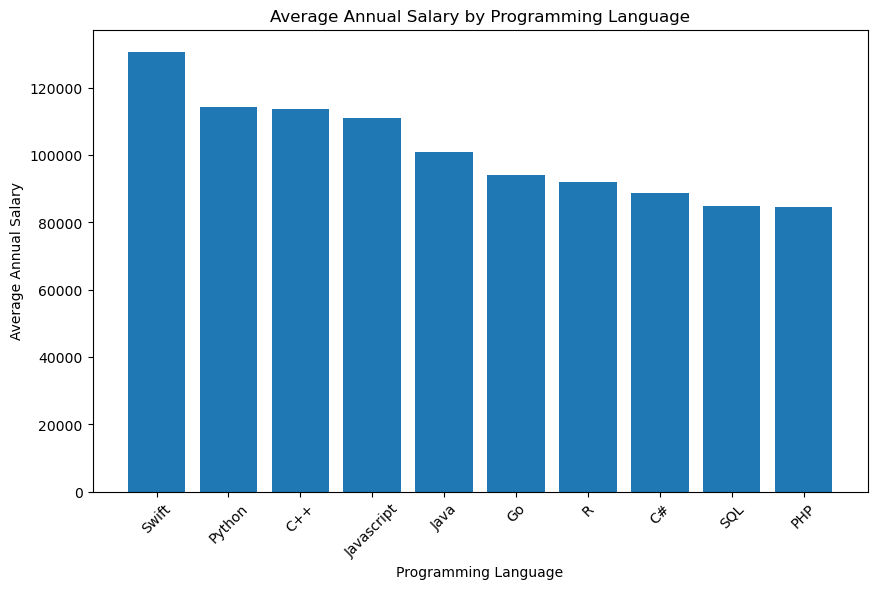

In [19]:

# your code goes here
df = pd.DataFrame({
    "Language_Name": languages,
    "Average Annual Salary": salaries
})

df["Average Annual Salary"] = df["Average Annual Salary"].replace('[\$,]', '', regex=True).astype(float)
df = df.sort_values(by="Average Annual Salary", ascending=False)
df.to_csv("popular-languages.csv", index=False)


# create bar chart
plt.figure(figsize=(10,6))
plt.bar(df["Language_Name"], df["Average Annual Salary"])
plt.title("Average Annual Salary by Programming Language")
plt.xlabel("Programming Language")
plt.ylabel("Average Annual Salary")
plt.xticks(rotation=45)
plt.show()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
